In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv('D:\DEV VELLY\Datasets\student_mental_health_burnout.csv')

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\HASEEB\AppData\Local\Temp\ipykernel_11048\4043315973.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('D:\DEV VELLY\Datasets\student_mental_health_burnout.csv')


In [3]:
df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [4]:
df.isnull().sum()

student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  str    
 3   course                   150000 non-null  str    
 4   year                     150000 non-null  str    
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  str    
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  physical_activi

<Axes: xlabel='stress_level', ylabel='Count'>

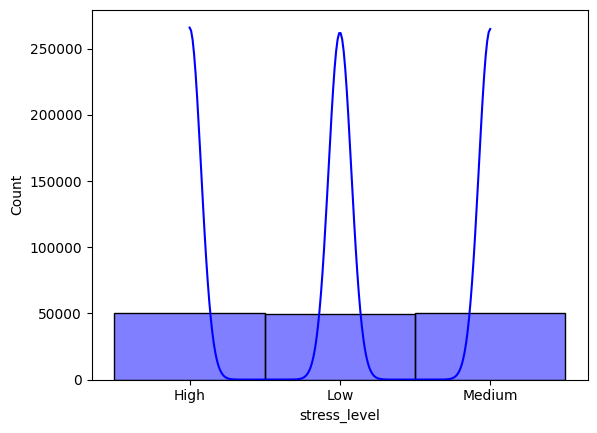

In [14]:
sns.histplot(df['stress_level'], kde=True, color = 'blue')

<Axes: >

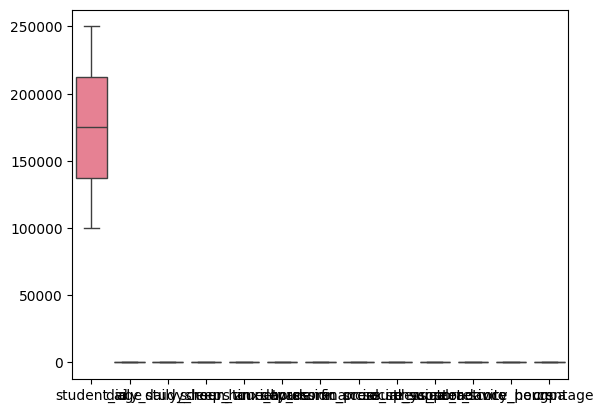

In [10]:
sns.boxplot(df)

In [15]:
df.columns

Index(['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours',
       'daily_sleep_hours', 'screen_time_hours', 'stress_level',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'sleep_quality', 'attendance_percentage',
       'cgpa', 'internet_quality', 'burnout_level'],
      dtype='str')

In [16]:
df

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,249996,24,Female,BSc,3rd,1.6,8.2,11.3,Medium,9,9,5,3,10,2.0,Good,54.2,7.82,Good,Low
149996,249997,25,Male,BCA,3rd,9.9,4.8,1.6,High,10,3,10,10,2,0.1,Poor,53.6,7.19,Average,High
149997,249998,22,Male,BTech,1st,1.4,4.4,4.6,High,10,8,6,4,7,1.6,Good,90.7,9.78,Average,High
149998,249999,19,Male,BSc,3rd,1.5,4.3,1.1,Medium,8,6,5,7,4,1.1,Average,83.9,9.88,Average,Medium
